In [5]:
import sys
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du
from Pipeline1_SNR_datasets import execute_specsnr_algorithm

plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

In [6]:
df = pd.read_parquet("/home/2649/repos/spec_res/data/forSNR/dataset.parquet")
wvl, spectra, df_meta = du.unpack_dataset(df)
subtypes = df_meta["SN Subtype"].unique()

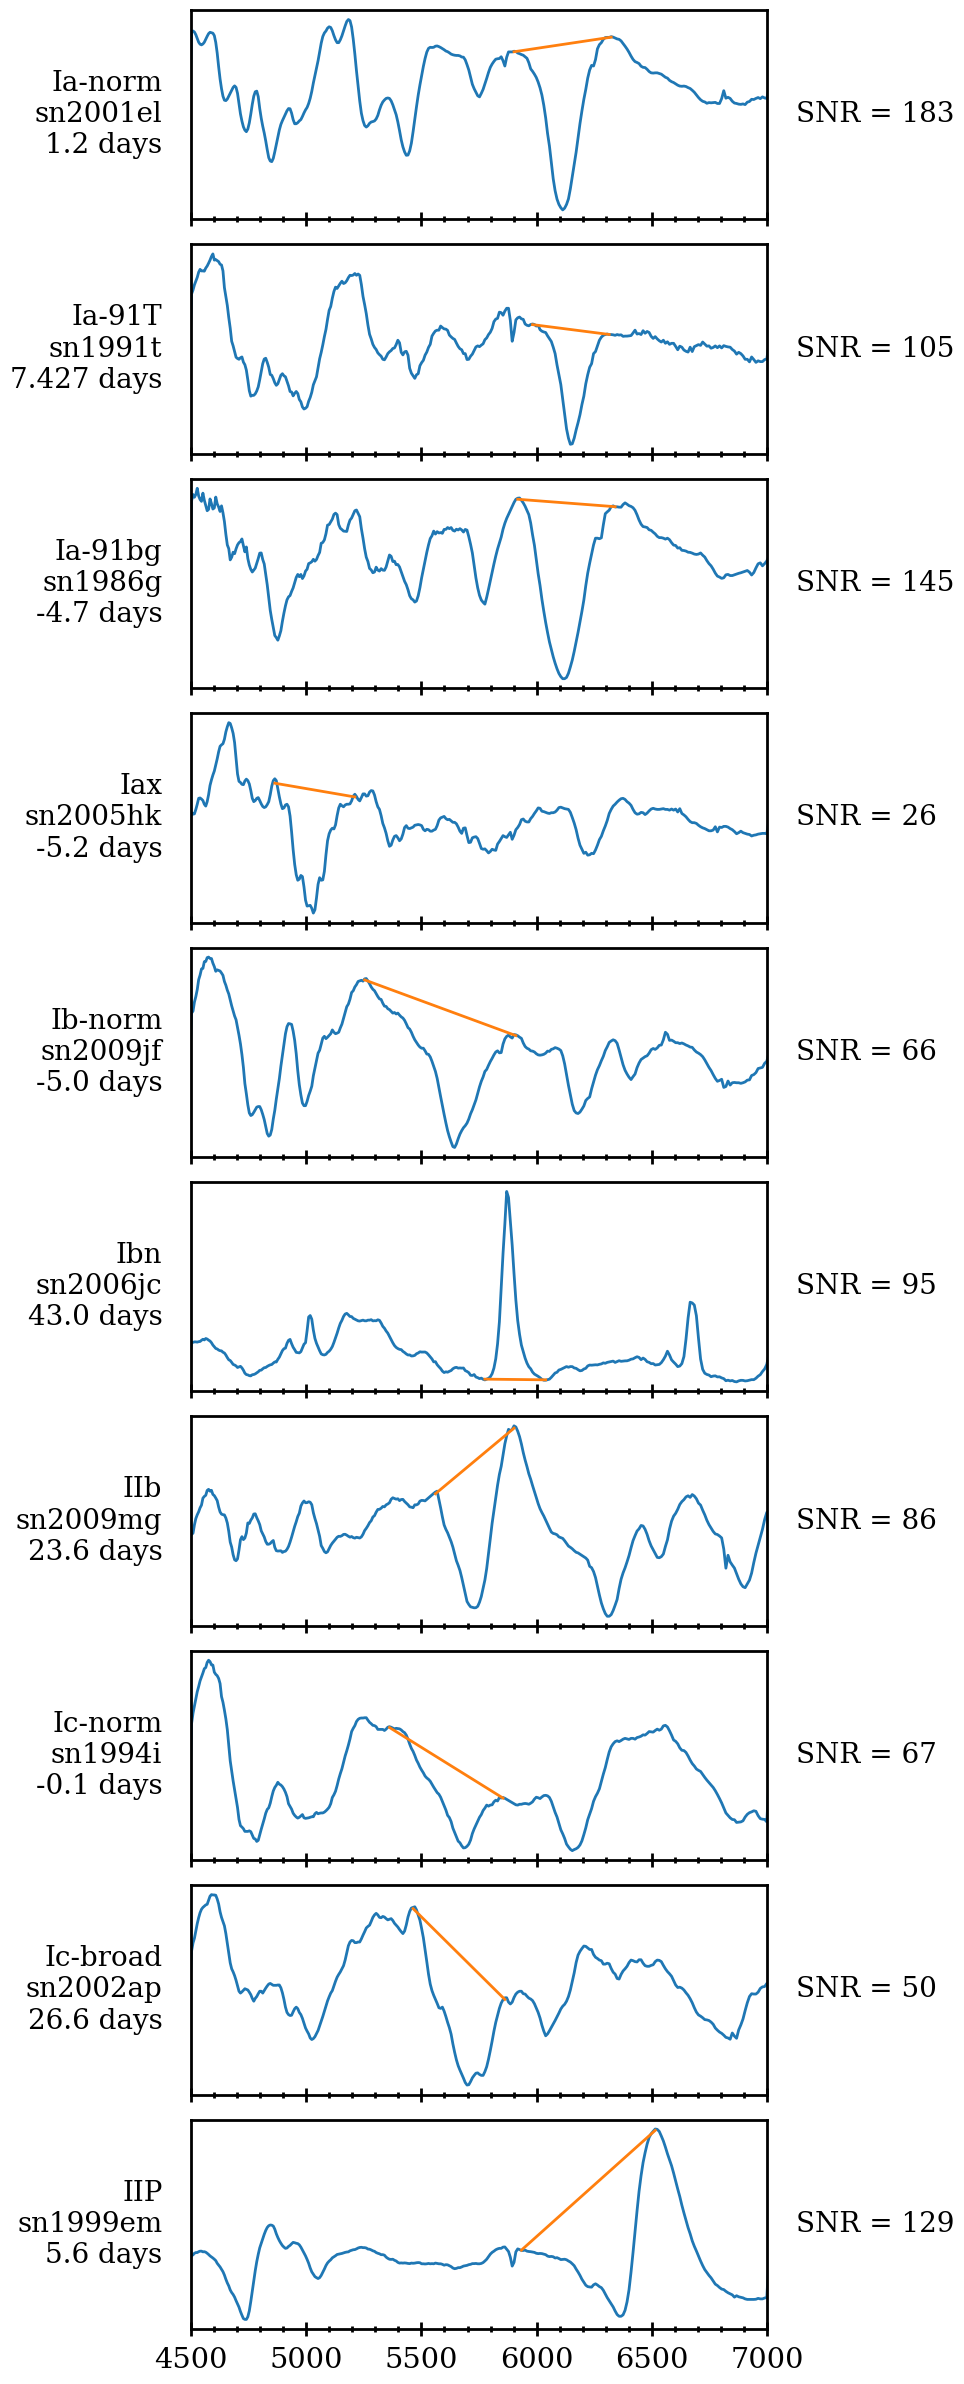

In [23]:
fig, axes = plt.subplots(nrows=10, ncols=1, sharex=True, figsize=(10, 24))


for j, subtype in enumerate(subtypes):
    mask = df_meta["SN Subtype"] == subtype
    highest_SNR = np.max(df_meta.loc[mask, "SNR"])
    mask &= df_meta["SNR"] == highest_SNR
    assert mask.sum() == 1
    spec_ind = df_meta.loc[mask].index[0]

    specsnr = ms.SpectrumSNR(
        df_meta.loc[spec_ind, "SN Name"],
        df_meta.loc[spec_ind, "SN Subtype"],
        df_meta.loc[spec_ind, "Spectrum Phase"],
        wvl,
        spectra[spec_ind])
    
    execute_specsnr_algorithm(
        specsnr,
        df_meta.loc[spec_ind, "Denoising Parameter"],
        df_meta.loc[spec_ind, "minima_i"],
        df_meta.loc[spec_ind, "searchBlu"],
        df_meta.loc[spec_ind, "searchRed"],
        df_meta.loc[spec_ind, "maxBlu"],
        df_meta.loc[spec_ind, "maxRed"],
        df_meta.loc[spec_ind, "noiseWindowBlu"],
        df_meta.loc[spec_ind, "noiseWindowRed"],
        df_meta.loc[spec_ind, "useBlu"],
        df_meta.loc[spec_ind, "useRed"],
        normalize=True)

    axes[j].plot(wvl, spectra[spec_ind])
    axes[j].plot(specsnr.pc_wvl, specsnr.pseudo_cont)
    axes[j].tick_params(
        axis="both",
        which="both",
        direction="inout",
        bottom=True, top=False, left=False, right=False)
    axes[j].set_yticklabels([])
    
    name = df_meta.loc[mask, 'SN Name'].item()
    if name[0] == "u":
        name = name[1:]
    subtype_confirm = df_meta.loc[mask, 'SN Subtype'].item()
    phase = df_meta.loc[mask, 'Spectrum Phase'].item()
    SNR = df_meta.loc[mask, "SNR"].item()
    
    axes[j].text(
        -0.05,
        0.5,
        f"{subtype_confirm}\n{name}\n{phase} days",
        ha="right", va="center",
        size=20,
        transform=axes[j].transAxes)

    axes[j].text(
        1.05,
        0.5,
        f"SNR = {SNR:.0f}",
        ha="left", va="center",
        size=20,
        transform=axes[j].transAxes)

axes[0].set_xlim((4500, 7000))
fig.tight_layout()
fig.show()